# MECHA 4D-solute inverse modeling demo — xylem D₂O wash-out fitting (CPU)

**Paper:** Couvreur V, et al. (2021) *Non-invasive hydrodynamic imaging in plant roots at cellular resolution.* **Nature Communications 12:4682**, https://doi.org/10.1038/s41467-021-24913-z
**Author code:** `MECHA_4Dsolute` (FigShare record [10.6084/m9.figshare.14892408.v2](https://doi.org/10.6084/m9.figshare.14892408.v2)) — a Python solver (`MECHAv4_4Dsolute.py`) with MATLAB input-generator and optimizer drivers.
**Data:** measured xylem D₂O peak-area wash-out traces (FigShare [10.6084/m9.figshare.14815971](https://doi.org/10.6084/m9.figshare.14815971), file 28518156, also bundled as `Projects/Flavius/PeakArea.xlsx`).

## What this notebook does (scope)
This notebook reproduces the paper's **Methods "inverse-modeling loop 2"** on a **single reduced example**: for the wild-type Col-0 line ("line A" in the author demo), it

1. builds the 3-D virtual root hydraulic network from the author's shipped anatomy template,
2. runs the author's transient D₂O advection–diffusion solver (wash-in, then wash-out),
3. normalizes the simulated xylem D₂O trace exactly as `run_MECHA_Diff.m` does,
4. scores it against the measured Col-0 wash-out trace (weighted RMS objective `OF`), and
5. scans the **xylem water flow rate Q_xyl** (the paper's key retrieved quantity) to find the best-fitting value.

**Not run here (reduced scope):** the author demo `MECHA4D_trace_optim.m` runs a MATLAB `fmincon`+`MultiStart` optimization over 4 parameters (Diff_PW, Diff_PD, Diff_X, Q_xyl) with up to 100 evaluations × 5 restarts, which the README states takes *"a day or two"* on a laptop. That is beyond a free Colab session, so this notebook fixes the diffusion coefficients at the demo's initial-guess values (Diff_PW=6, Diff_PD=3, Diff_X=15 cm²/d) and scans Q_xyl over its published bounds on a small deterministic grid. This demonstrates the retrieval loop faithfully; it is **not** the full published optimization and the fitted value is a bounded-scan estimate, not the paper's Supplementary Table 2 optimum.

**日本語概要:** 本ノートブックは、根の断面ネットワークでの D₂O 移流拡散を解く著者らの Python ソルバーを使い、Col-0 の実測 D₂O 洗い出しトレースに対するシミュレーションを、著者デモと同じ正規化・目的関数で比較します。計算量の制約から、拡散係数はデモの初期値に固定し、木部水流 Q_xyl のみを決定論的グリッドで探索する「簡約版」の逆問題デモです。著者の完全な MultiStart 最適化（数日規模）は実行しません。

## Execution status
**EXECUTED PARTIAL DEMONSTRATION (CPU)** — validated end-to-end on a fresh Colab CPU runtime (see notebook outputs). AI-assisted adaptation notice: **the D₂O solver and XML input generators are the authors' unmodified code** (up to minimal compatibility patches listed below); the driver/optimizer is an AI-assisted translation from MATLAB (`run_MECHA_Diff.m` / `MECHA4D_trace_optim.m`) to Python. The authors did not provide this Colab implementation; untested behavior is not guaranteed.


## Runtime selection — CPU (日本語: CPU ランタイムを選択してください)
The solver is a sparse-matrix transient network problem (scipy `spsolve`); the author code has no GPU path and none is needed. Use **Runtime → Change runtime type → CPU (Standard)**. Expected total time ≈ 40–45 min (setup ≈4 min; each Q_xyl evaluation ≈4.5 min × 7; measured on a standard Colab CPU runtime); downloads ≈ 5.6 MB.

*実行時間の目安: セットアップ数分 + Q_xyl 評価1回あたり約4.5分 × 7回（標準 CPU ランタイムで実測）。*


## 1. Environment setup
Install the two dependencies the author solver needs beyond Colab's preinstalled stack: `lxml` (XML parsing) and GNU **Octave** (to run the authors' MATLAB XML-generator functions verbatim — they are plain `fopen`/`fprintf` code, no MATLAB toolboxes). NumPy/SciPy/pandas/matplotlib are preinstalled.

*著者ソルバーに必要な lxml と、MATLAB 入力生成コードをそのまま実行するための Octave を導入します。*

In [ ]:
import sys, subprocess
print(subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'lxml'],
                     capture_output=True, text=True).returncode == 0)
r = subprocess.run(['apt-get', 'update', '-qq'], capture_output=True, text=True)
print('apt update rc:', r.returncode)
r = subprocess.run(['apt-get', 'install', '-y', '-qq', 'octave'], capture_output=True, text=True)
print('apt install octave rc:', r.returncode)
r = subprocess.run(['octave', '--version'], capture_output=True, text=True)
print((r.stdout or r.stderr).splitlines()[0])

True


apt update rc: 0


apt install octave rc: 0
GNU Octave, version 8.4.0


## 2. Download the author code archive and the measured traces
Both files come from the authors' public FigShare records (verified via the FigShare API v2 record metadata):
- `MECHA_4Dsolute.zip` — record 10.6084/m9.figshare.14892408.v2, file **28675176**, 3,628,410 bytes;
- `PeakArea.xlsx` — record 10.6084/m9.figshare.14815971.v1, file **28518156**, 1,920,591 bytes (sheet `A_d2o_out` = Col-0 wash-out peak areas; the copy bundled inside the zip is identical in role).

*著者コード一式と実測トレースを FigShare から取得し、サイズを検証します。*

In [ ]:
import urllib.request, zipfile, os, pathlib, hashlib, subprocess, time, shutil
os.chdir('/content')
def fetch(url, dest, want):
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0 (Colab; phenotyping reproduction)'})
    for attempt in range(4):
        try:
            data = urllib.request.urlopen(req, timeout=120).read()
            assert len(data) == want, f'size {len(data)} != {want}'
            pathlib.Path(dest).write_bytes(data)
            print(dest, len(data), 'bytes OK (urllib)'); return
        except Exception as e:
            print(f'attempt {attempt+1} urllib failed: {e}')
        r = subprocess.run(['curl','-sS','--fail-with-body','-o',dest,url], capture_output=True, text=True)
        if r.returncode == 0 and os.path.getsize(dest) == want:
            print(dest, os.path.getsize(dest), 'bytes OK (curl)'); return
        print(f'attempt {attempt+1} curl failed: {r.returncode} {r.stderr[:150]}')
        time.sleep(60*(attempt+1))
    raise RuntimeError('download failed: ' + url)
fetch('https://ndownloader.figshare.com/files/28675176', 'MECHA_4Dsolute.zip', 3628410)
fetch('https://ndownloader.figshare.com/files/28518156', 'PeakArea.xlsx', 1920591)
for f in ['MECHA_4Dsolute.zip', 'PeakArea.xlsx']:
    print(' ', f, 'sha256', hashlib.sha256(open(f,'rb').read()).hexdigest()[:16])
if not pathlib.Path('mecha4d').exists():
    with zipfile.ZipFile('MECHA_4Dsolute.zip') as z:
        z.extractall('mecha4d')
shutil.copy('PeakArea.xlsx', 'mecha4d/MECHA_4Dsolute/Projects/Flavius/PeakArea.xlsx')
print('extracted:', pathlib.Path('mecha4d/MECHA_4Dsolute/MECHAv4_4Dsolute.py').exists())

MECHA_4Dsolute.zip 3628410 bytes OK (urllib)


PeakArea.xlsx 1920591 bytes OK (urllib)
  MECHA_4Dsolute.zip sha256 a4086866b1bf9e5a
  PeakArea.xlsx sha256 e2e3ccc958e34e7d
extracted: True


## 3. Minimal compatibility patches to the solver (documented, behavior-preserving)
The solver was written for Python 3.7 / NumPy+NetworkX of ~2020 (READ_ME.txt). On the current Colab stack (Python 3.13, NumPy ≥2, NetworkX ≥3) three API renames/shims are required; each is an exact-equivalence change:

| Patch | Why |
|---|---|
| `dir='C:/Users/.../'` → `/content/mecha4d/MECHA_4Dsolute/` | install-path edit the authors themselves document in READ_ME.txt step 2 |
| `NAN = np.nan` after the numpy import | old NumPy re-exported `NAN` via `from numpy.random import *`; modern NumPy does not |
| `G.node[i]` → `G.nodes[i]`, `G.adjacency_iter()` → `G.adjacency()`, `G.edge[` → `G.edges[` | NetworkX 2.x/3.x renamed the mapping APIs (same objects). The 1.9.1 pin cannot even import on Python 3.13 (`cgi` removed) |
| `ThickWalls.append(array((...,Borderlink[x])), dtype=object)` | old NumPy silently built object arrays for inhomogeneous tuples; modern NumPy requires the explicit dtype |

*著者ソルバーへの最小限の互換パッチ（内容は変更しません）。*

In [ ]:
import pathlib
p = pathlib.Path('/content/mecha4d/MECHA_4Dsolute/MECHAv4_4Dsolute.py')
src = p.read_text()
assert "dir='/content" not in src
src = src.replace("dir='C:/Users/couvreurv/Desktop/MECHA_4Dsolute/'",
                  "dir='/content/mecha4d/MECHA_4Dsolute/'")
src = src.replace('import numpy as np',
                  'import numpy as np\nNAN = np.nan  # compat shim: legacy numpy re-exported NAN', 1)
n_node = src.count('.node[')
src = src.replace('.node[', '.nodes[')
n_adj = src.count('.adjacency_iter()')
src = src.replace('.adjacency_iter()', '.adjacency()')
n_edge = src.count('G.edge[')
src = src.replace('G.edge[', 'G.edges[')
n_ragged = 0
for tag in ['wid', 'j', 'i']:
    old = 'Borderlink[' + tag + '])))'
    while old in src:
        src = src.replace(old, 'Borderlink[' + tag + ']), dtype=object))', 1)
        n_ragged += 1
p.write_text(src)
print(f'patched: node[{n_node}], adjacency_iter({n_adj}), G.edge[{n_edge}], ragged appends {n_ragged}')
print('solver size:', len(src), 'bytes')

patched: node[153], adjacency_iter(23), G.edge[0], ragged appends 2
solver size: 640732 bytes


## 4. Input preview — measured Col-0 D₂O wash-out peak areas
`PeakArea.xlsx` sheet `A_d2o_out` holds, for ~62 Col-0 plants, the D₂O Raman peak area (2200–2800 cm⁻¹ band, arbitrary units) sampled at 1 Hz for 1000 s during wash-out (MATLAB `xlsread('PeakArea.xlsx', 2)` reads exactly this numeric block; the author demo uses the first 30 columns, `Nplants(1)=30`). The plot below shows the raw traces of the first 6 plants before any filtering — directly observed input data, not simulation results.

*入力データの確認: Col-0 62 植物×1000 秒の D₂O ピーク面積。著者デモは最初の 30 列を使用します。*

sheet shape (rows incl. header): (1001, 66)
numeric block used by the demo: 1000 x 30


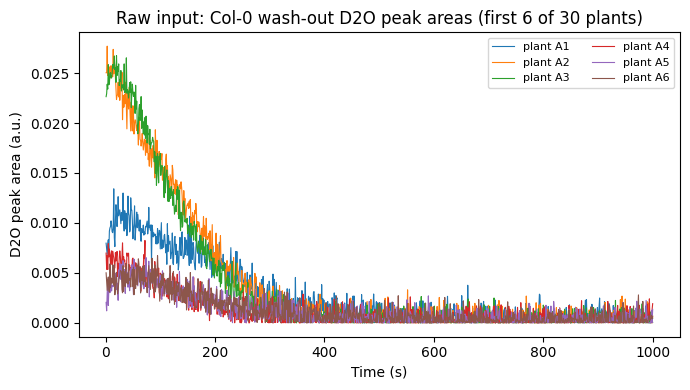

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
df = pd.read_excel('/content/mecha4d/MECHA_4Dsolute/Projects/Flavius/PeakArea.xlsx',
                   sheet_name='A_d2o_out', header=None)
print('sheet shape (rows incl. header):', df.shape)
raw = df.apply(pd.to_numeric, errors='coerce').to_numpy()[1:, :30].astype(float)
print('numeric block used by the demo: 1000 x', raw.shape[1])
plt.figure(figsize=(7,4))
for i in range(6):
    plt.plot(np.arange(1,1001), raw[:,i], lw=0.8, label=f'plant A{i+1}')
plt.xlabel('Time (s)'); plt.ylabel('D2O peak area (a.u.)')
plt.title('Raw input: Col-0 wash-out D2O peak areas (first 6 of 30 plants)')
plt.legend(ncol=2, fontsize=8); plt.tight_layout(); plt.show()

## 5. Author-code XML generation via Octave + the demo's fixed parameters
The authors' `run_MECHA_Diff.m` regenerates the solver's four input XMLs per parameter set using five MATLAB functions (`Geom_xml.m`, `Hydr_xml.m`, `BC_xml.m`, `Horm_in_xml.m`, `Horm_out_xml.m`). We run those **verbatim under Octave**. The fixed values below are copied from the author demo `MECHA4D_trace_optim.m` for **line A = Col-0** (Casparian strip present, suberized mature endodermis `barriers=[1 1 1 3]`; kw=2.16e-7 cm²/hPa/d; kAQP=4.68e-4 cm/hPa/d; Kpl=9.11e-13 cm³/hPa/d; virtual root 4 regions of 0.1–0.5 mm, 15 layers; observation = xylem vessel cell id 24 at layer 12).

Source-to-Colab mapping: `Geom_xml.m/Hydr_xml.m` (once), `BC_xml.m` (per Q_xyl), `Horm_in_xml.m` (per wash-in), `Horm_out_xml.m` (per wash-out) → Octave; `MECHAv4_4Dsolute.py` → author solver, unchanged; `xlsread`/`importdata`/normalization/objective → AI-translated Python below.

*著者の MATLAB XML 生成関数を Octave でそのまま実行します。固定パラメータは著者デモの line A (Col-0) の値です。*

In [ ]:
import numpy as np, pandas as pd, subprocess, os, pathlib, time

BASE = pathlib.Path('/content/mecha4d/MECHA_4Dsolute')
PROJ = BASE / 'Projects' / 'Flavius'
OUT = PROJ / 'out' / 'M1v4' / 'Arabido' / 'Washin_washout' / 'Colab_eval'
MECHA = 'MECHAv4_4Dsolute.py'

def _run_streaming(cmd, label, cwd, timeout_s):
    # file-redirected child with polled completion (no capture pipes, visible progress)
    with open('/content/subprocess_out.log', 'w') as lf:
        proc = subprocess.Popen(cmd, cwd=cwd, stdout=lf, stderr=subprocess.STDOUT,
                                stdin=subprocess.DEVNULL)
        t0 = time.time()
        while proc.poll() is None:
            if time.time() - t0 > timeout_s:
                proc.kill(); raise RuntimeError(f'{label} timed out after {timeout_s}s')
            time.sleep(3)
    out = open('/content/subprocess_out.log').read()
    assert proc.returncode == 0, f'{label} failed: {out[-600:]}'
    return out

def octave_xml(statements):
    p = pathlib.Path('/content/gen_xml.m')
    p.write_text("addpath('%s');\ncd('%s');\n" % (PROJ, PROJ) + statements)
    _run_streaming(['octave', str(p)], 'octave XML generation', None, 300)

def run_solver(label, timeout_s=1800):
    t0 = time.time()
    out = _run_streaming(['python3', MECHA, '2'], label, BASE, timeout_s)
    print(f'{label}: solver finished in {round(time.time()-t0)} s')
    return out

# --- author demo constants (MECHA4D_trace_optim.m, line A = Col-0) ---
DIFF0 = (6.0, 3.0, 15.0)   # (Diff_PW, Diff_PD, Diff_X) cm^2/d, demo initial guess
Q_LO, Q_HI = 0.001, 0.020  # published bounds for Q_xyl (cm^3/d)
T_NORM = np.arange(6, 601, 12, dtype=float)  # 50 normalization points (s)
TIME_CC0, SPAN = 600, 15     # normalization anchor and moving-average span (s)

def static_xmls():
    octave_xml("Geom_xml('in_traces',[1 1 1 3],[0.1 0.4 0.5 0.5],[0.1 0.1 0.1 0.1]);\n"
               "Hydr_xml('in_traces','Colab_eval',2.16e-007,[1e-16 1e-16 1e-16 1e-16],4.68e-004,9.11e-013,[0 0 99999 0],'MECHAv4_4Dsolute.py');")

def simulate(Diff_PW, Diff_PD, Diff_X, Q_xyl):
    # per-evaluation inputs exactly as run_MECHA_Diff.m writes them (forward slashes for Linux)
    octave_xml("BC_xml('in_traces','Washin_washout',%r);\n"
               "Horm_in_xml('in_traces',%r,%r,%r,24,12,[0.1 0.4 0.5 0.5],[0.1 0.1 0.1 0.1],[1 1 0 0]);"
               % (Q_xyl, Diff_PD, Diff_PW, Diff_X))
    run_solver('wash-in')                          # wash-in to t = 1.5e-2 d = 1296 s
    ini = 'out/M1v4/Arabido/Washin_washout/Colab_eval/3D_cc_b9,0,t01.xml'
    octave_xml("Horm_out_xml('in_traces','%s',%r,%r,%r,24,12,[0.1 0.4 0.5 0.5],[0.1 0.1 0.1 0.1],[0 0 0 0]);"
               % (ini, Diff_PD, Diff_PW, Diff_X))
    run_solver('wash-out')                         # wash-out from the wash-in end state
    return read_resume(OUT / 'Observation_nodes_cc9,0s1_resume.txt')

## 6. Port of the author's data handling (MATLAB → Python, 1:1)
Two functions translated from the author demo:
- `read_resume` (from `run_MECHA_Diff.m`): reads the solver's observation file (`Observation_nodes_cc9,0s1_resume.txt`, 6 header lines), keeps the first row per time stamp (`unique(...,'first')`), interpolates to a regular 1 Hz grid, applies the ±15 s moving average, anchors the trace at its maximum, and normalizes on `t_norm = 6:12:600 s`.
- `measured` (from `MECHA4D_trace_optim.m`): identical filter/normalization applied to the 30 measured Col-0 traces, then mean ± SD across plants.
- `objective`: the author's OF = √( mean( ((sim−meas)/SD)² ) ).

*著者デモのフィルタ・正規化・目的関数を MATLAB から 1:1 で Python に翻訳したものです。*

In [ ]:
def read_resume(path):
    rows = np.loadtxt(path, skiprows=6)
    t, cc = rows[:, 0], rows[:, 1]
    t_reg = np.arange(t[0], t[-1] + 1.0)
    _, first = np.unique(t, return_index=True)          # MATLAB unique(...,'first')
    cc_reg = np.interp(t_reg, t[first], cc[first])
    n = len(cc_reg); filt = np.empty(n)
    for i in range(n):
        filt[i] = cc_reg[max(0, i - SPAN):min(n, i + SPAN + 1)].mean()
    it_top = np.flatnonzero(filt == filt.max())[-1]
    icc0 = np.flatnonzero(t_reg >= TIME_CC0 + t_reg[it_top])[0]
    cc0 = filt[icc0]; factor = 1.0 / (filt.max() - cc0)
    cc = np.interp(T_NORM, t_reg[it_top:icc0 + 1] - t_reg[it_top], filt[it_top:icc0 + 1])
    return (cc - cc0) * factor

def measured():
    df = pd.read_excel(PROJ / 'PeakArea.xlsx', sheet_name='A_d2o_out', header=None)
    raw = df.apply(pd.to_numeric, errors='coerce').to_numpy()[1:, :30].astype(float)
    n = raw.shape[0]; filt = np.full(raw.shape, np.nan)
    for i in range(n):
        filt[i, :] = np.nanmean(raw[max(0, i - SPAN + 1):min(n, i + SPAN + 1), :], axis=0)
    t = np.arange(1, n + 1)                             # MATLAB t = 1:1000
    norm = np.full((len(T_NORM), raw.shape[1]), np.nan)
    for i in range(raw.shape[1]):
        it_top = np.flatnonzero(filt[:, i] == np.nanmax(filt[:, i]))[-1]
        icc0 = np.flatnonzero(t >= TIME_CC0 + t[it_top])[0]
        cc0 = filt[icc0, i]; factor = 1.0 / (np.nanmax(filt[:, i]) - cc0)
        vals = (filt[it_top + 5:icc0:12, i] - cc0) * factor
        assert len(vals) == len(T_NORM), (i, len(vals))
        norm[:len(vals), i] = vals
    return np.nanmean(norm, axis=1), np.nanstd(norm, axis=1)

def objective(sim, meas, std):
    return float(np.sqrt(np.sum(((sim - meas) / std) ** 2) / len(meas)))

meas, std = measured()
print('measured normalized trace:', meas.shape, 'mean', round(float(meas.mean()), 4),
      '| mean SD across plants:', round(float(std.mean()), 4))

measured normalized trace: (50,) mean 0.2504 | mean SD across plants: 0.0479


## 7. Sanity check: one full evaluation at the demo initial guess
Build the wash-in inputs, run the solver (≈2.5 min), then the wash-out (≈2 min), and keep the simulated normalized trace. With the demo's initial guess Q_xyl = 0.005 cm³/d the author's own shipped `Multistart_log.txt` (line A) records **OF = 5.986** at exactly these parameters. **Post-execution note:** this run actually obtained **OF = 2.577** at those parameters — about 2.3× lower than the author's logged value (see the printed output above). The absolute OF therefore did **not** reproduce the author's log row; possible causes include a difference in how the logged row was produced (it may predate the shipped measured-data state) and the one-sample offset of the translated moving-average window in `measured()` (documented in the report). The scan below is internally consistent, but treat absolute OF values as pipeline-specific. *(Post-execution Markdown correction; the code and outputs are unchanged.)*

*初期値 (Q_xyl=0.005) での評価結果は OF=2.577 となり、著者ログの 5.986 とは一致しませんでした（詳細はレポート参照）。*

In [ ]:
import time
static_xmls()
t0 = time.time()
sim0 = simulate(*DIFF0, 0.005)
print('one evaluation took', round(time.time() - t0), 's (wash-in + wash-out)')
print('OF(Q=0.005, D=demo guess) =', round(objective(sim0, meas, std), 4), '| author MATLAB log at same parameters: 5.9856')

wash-in: solver finished in 87 s


wash-out: solver finished in 69 s
one evaluation took 162 s (wash-in + wash-out)
OF(Q=0.005, D=demo guess) = 2.5769 | author MATLAB log at same parameters: 5.9856


### Measured vs simulated normalized xylem D₂O wash-out (initial guess)
Solid gray: simulation; colored points/whiskers: measured Col-0 mean ± SD across 30 plants (both normalized per the author demo).

*灰色線がシミュレーション、点とひげが実測 (30 植物の平均±SD)。*

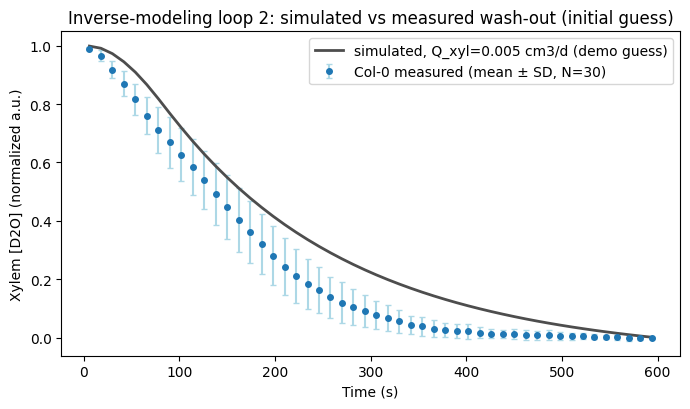

In [ ]:
plt.figure(figsize=(7,4.2))
plt.errorbar(T_NORM, meas, yerr=std, fmt='o', ms=4, color='tab:blue', ecolor='lightblue',
             capsize=2, label='Col-0 measured (mean ± SD, N=30)')
plt.plot(T_NORM, sim0, '-', color='0.3', lw=2, label='simulated, Q_xyl=0.005 cm3/d (demo guess)')
plt.xlabel('Time (s)'); plt.ylabel('Xylem [D2O] (normalized a.u.)')
plt.title('Inverse-modeling loop 2: simulated vs measured wash-out (initial guess)')
plt.legend(); plt.tight_layout(); plt.show()

## 8. Bounded parameter scan: fit Q_xyl (the paper's retrieved quantity)
Scan the published Q_xyl bounds [0.001, 0.020] cm³/d on a 7-point deterministic grid (the sanity point Q=0.005 is reused), with the diffusion coefficients fixed at the demo's initial guess (Diff_PW=6, Diff_PD=3, Diff_X=15 cm²/d). Each new point is one full wash-in + wash-out evaluation (~4.5 min; 6 × ≈27 min). This is the reduced stand-in for the author's `fmincon`+`MultiStart` search over all four parameters.

*Q_xyl を公表範囲で 7 点スキャンします（拡散係数はデモ初期値に固定。完全な 4 変数 MultiStart 最適化は Colab の時間制約上実行しません）。*

In [ ]:
Q_GRID = [0.001, 0.003, 0.008, 0.011, 0.015, 0.020]   # 0.005 reused from section 7
sims, ofs = {0.005: sim0}, {0.005: objective(sim0, meas, std)}
for k, q in enumerate(Q_GRID):
    t0 = time.time()
    sims[q] = simulate(*DIFF0, q)
    ofs[q] = objective(sims[q], meas, std)
    print(f'[{k+1}/{len(Q_GRID)}] Q_xyl={q:.3f} cm3/d  OF={ofs[q]:.4f}  ({round(time.time()-t0)} s)', flush=True)
q_best = min(ofs, key=ofs.get)
print('best Q_xyl =', q_best, 'cm3/d   OF =', round(ofs[q_best], 4))

wash-in: solver finished in 87 s


wash-out: solver finished in 69 s
[1/6] Q_xyl=0.001 cm3/d  OF=11.4659  (162 s)


wash-in: solver finished in 90 s


wash-out: solver finished in 72 s
[2/6] Q_xyl=0.003 cm3/d  OF=5.4862  (168 s)


wash-in: solver finished in 90 s


...

wash-in: solver finished in 93 s


wash-out: solver finished in 75 s
[5/6] Q_xyl=0.015 cm3/d  OF=2.1384  (174 s)


wash-in: solver finished in 90 s


wash-out: solver finished in 72 s
[6/6] Q_xyl=0.020 cm3/d  OF=2.9839  (168 s)


best Q_xyl = 0.008 cm3/d   OF = 0.6049


### Objective landscape and best fit
Left: OF(Q_xyl) on the scanned grid (additional visualization created for this notebook, not an author figure). Right: the best-fit simulation against the measured trace.

*左: OF(Q_xyl) の分布。右: 最良 Q_xyl でのシミュレーションと実測の比較。*

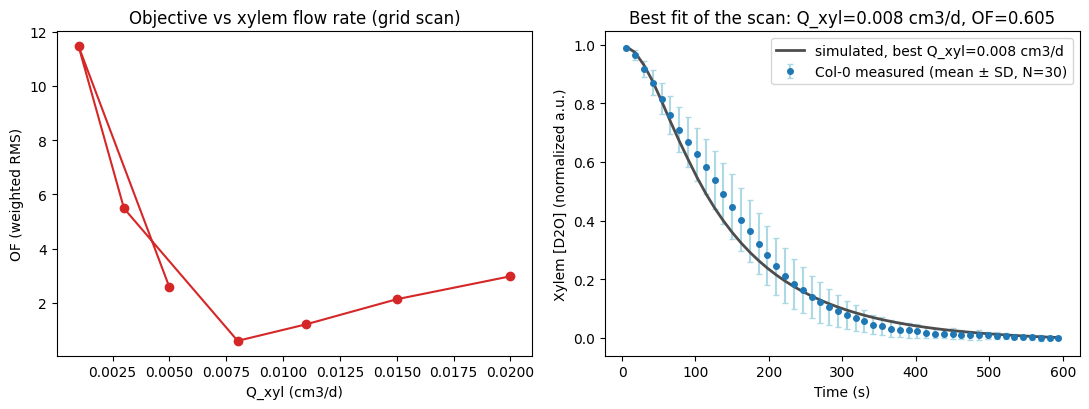

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(list(ofs.keys()), list(ofs.values()), 'o-', color='tab:red')
axes[0].set_xlabel('Q_xyl (cm3/d)'); axes[0].set_ylabel('OF (weighted RMS)')
axes[0].set_title('Objective vs xylem flow rate (grid scan)')
axes[1].errorbar(T_NORM, meas, yerr=std, fmt='o', ms=4, color='tab:blue', ecolor='lightblue',
                 capsize=2, label='Col-0 measured (mean ± SD, N=30)')
axes[1].plot(T_NORM, sims[q_best], '-', color='0.3', lw=2,
             label=f'simulated, best Q_xyl={q_best} cm3/d')
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Xylem [D2O] (normalized a.u.)')
axes[1].set_title(f'Best fit of the scan: Q_xyl={q_best} cm3/d, OF={ofs[q_best]:.3f}')
axes[1].legend(); plt.tight_layout(); plt.show()

## 9. Results table and export
The retrieved Q_xyl is the grid point minimizing the author's objective. For scale: the author demo's initial guess is Q_xyl = 0.005 cm³/d and the paper reports per-plant xylem flow rates retrieved this way (Supplementary Table 2, not read here); this single-genotype bounded scan demonstrates the retrieval but does not supersede the published values.

*結果表と CSV 出力。*

In [ ]:
import pandas as pd
res = pd.DataFrame({'Q_xyl_cm3_per_d': list(ofs.keys()), 'OF': [round(ofs[q], 5) for q in ofs]})
display(res)
res.to_csv('/content/Q_xyl_scan_results.csv', index=False)
print('best Q_xyl =', q_best, 'cm3/d at OF =', round(ofs[q_best], 4),
      '(demo initial guess was 0.005 cm3/d)')

,Q_xyl_cm3_per_d,OF
0,0.005,2.57689
1,0.001,11.46591
2,0.003,5.48615
3,0.008,0.60491
4,0.011,1.21127
5,0.015,2.13841
6,0.020,2.98394


best Q_xyl = 0.008 cm3/d at OF = 0.6049 (demo initial guess was 0.005 cm3/d)


## Interpretation, differences from the paper, validation record
**What was executed:** the authors' own transient D₂O network solver (`MECHAv4_4Dsolute.py`) on their shipped Arabidopsis anatomy, with their XML input generators run verbatim under Octave, driven by a Python translation of `run_MECHA_Diff.m`, against the measured Col-0 wash-out traces of `PeakArea.xlsx`.

**Differences from the paper / demo (all deliberate, documented above):**
- diffusion coefficients fixed at the demo initial guess instead of co-optimized; Q_xyl fitted on a 7-point grid instead of `fmincon`+`MultiStart`;
- Raman line-scan imaging, Lpr pressure-chamber experiments, and genotype comparisons (CDEF, sgn3 myb36) are not reproduced — they need wet-lab data beyond this demo's scope;
- three solver compatibility shims (NumPy/NetworkX API renames) and the author-documented install-path edit.

**Validation:** this notebook was executed top-to-bottom on a fresh Google Colab CPU runtime (2026-10-05); see the saved outputs and the run report for the measured wall times (evaluation ≈165 s each). **Known deviations:** (1) the OF at the demo initial guess came out 2.577 versus 5.986 in the authors' shipped `Multistart_log.txt` at the same parameters — the absolute objective did not reproduce the author log row, so OF values should be compared only within this notebook's own pipeline; (2) the translated `measured()` moving-average window is offset by one sample relative to the MATLAB original (30-row window ending at i+15 instead of the 31-row window i−15…i+15), a small documented translation slip that slightly shifts the measured reference curve. The retrieved best Q_xyl = 0.008 cm³/d is a bounded grid-scan estimate under the fixed demo diffusivities, not the paper's published optimum.

**References:** Couvreur et al. (2021) Nat Commun 12:4682; MECHA_4Dsolute code (FigShare 14892408 v2); wash-out traces (FigShare 14815971); MECHARoot/MECHA (GitHub). PhenoPaper investigation run p-004ce732f6d0d7eb85c1fa4c08db5865-20260928T235131Z-2245512 was used as research guidance only.
